In [1]:
import random as rnd

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from bluebikes_analysis.config import LOCAL_DATA_DIR
from bluebikes_analysis.plots import (
    COLORS,
    plot_daily_longterm,
    plot_hourly_weekly,
    plot_points_on_map,
)

In [3]:
timeseries_dir = LOCAL_DATA_DIR / "processed" / "timeseries"

system_file = timeseries_dir / "system/daily_trips_timeseries.csv"
system_df = pd.read_csv(system_file)

station_name = "B32003"
station_file = timeseries_dir / f"station/{station_name}_morning_demand.csv"

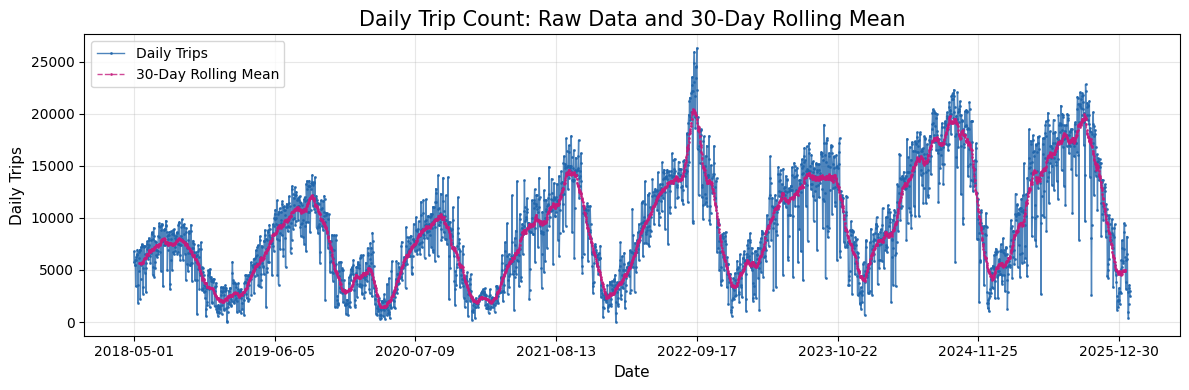

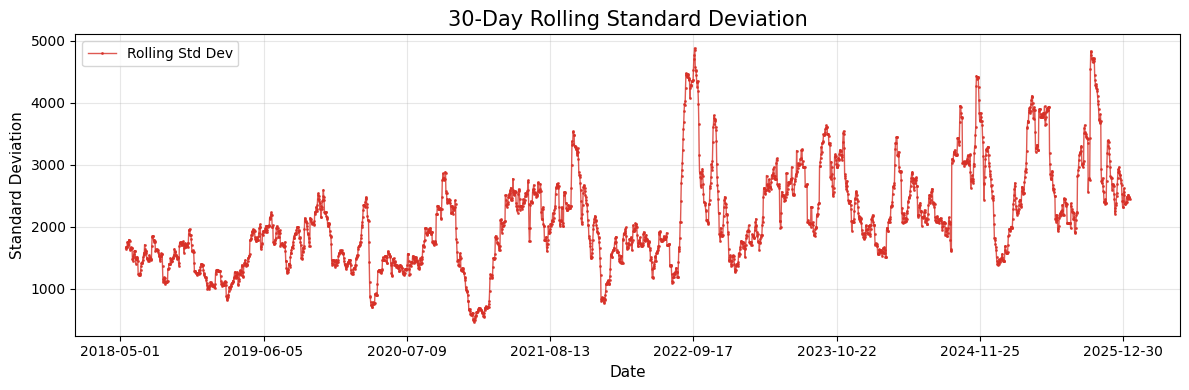

In [15]:
# Calculate rolling statistics (30-day window)
system_df = system_df.sort_values('date')
system_df['rolling_mean_30'] = system_df['trip_count'].rolling(window=30, center=True).mean()
system_df['rolling_std_30'] = system_df['trip_count'].rolling(window=30, center=True).std()

# Plot 1: Time series with rolling mean
plot_daily_longterm(
    system_df.set_index("date"),
    columns_to_plot=['trip_count', 'rolling_mean_30'],
    title='Daily Trip Count: Raw Data and 30-Day Rolling Mean',
    xlabel='Date',
    ylabel='Daily Trips',
    color_list=[COLORS[7], COLORS[1]],
    linestyle_list=['-', '--'],
    legend_labels=['Daily Trips', '30-Day Rolling Mean'],
    figsize=(12,4)
)

# Plot 2: Rolling standard deviation (separate plot)
plot_daily_longterm(
    system_df.set_index("date"),
    columns_to_plot=['rolling_std_30'],
    title='30-Day Rolling Standard Deviation',
    xlabel='Date',
    ylabel='Standard Deviation',
    color_list=[COLORS[3]],
    legend_labels=['Rolling Std Dev'],
    figsize=(12,4)
)

In [16]:
from statsmodels.tsa.stattools import adfuller

# Perform Augmented Dickey-Fuller test
result = adfuller(system_df['trip_count'].dropna(), autolag='AIC')

# Extract results
adf_statistic = result[0]
p_value = result[1]
n_lags = result[2]
n_obs = result[3]
critical_values = result[4]

# Print results
print("=" * 60)
print("AUGMENTED DICKEY-FULLER TEST")
print("=" * 60)
print(f"Null Hypothesis (H₀): Series has a unit root (non-stationary)")
print(f"Alternative (H₁): Series is stationary")
print()
print(f"Test Statistic:        {adf_statistic:.4f}")
print(f"P-value:               {p_value:.4f}")
print(f"Number of lags used:   {n_lags}")
print(f"Number of observations: {n_obs}")
print()
print("Critical Values:")
print(f"  1%:  {critical_values['1%']:.4f}")
print(f"  5%:  {critical_values['5%']:.4f}")
print(f"  10%: {critical_values['10%']:.4f}")
print()
print("=" * 60)
print("INTERPRETATION")
print("=" * 60)

if p_value < 0.01:
    print(f"✓ Reject H₀ at 1% significance (p={p_value:.4f} < 0.01)")
    print("  → Series is stationary")
elif p_value < 0.05:
    print(f"✓ Reject H₀ at 5% significance (p={p_value:.4f} < 0.05)")
    print("  → Series is stationary")
elif p_value < 0.10:
    print(f"~ Reject H₀ at 10% significance (p={p_value:.4f} < 0.10)")
    print("  → Weak evidence of stationarity")
else:
    print(f"✗ Fail to reject H₀ (p={p_value:.4f} > 0.10)")
    print("  → Series is NON-STATIONARY")
    
print()
print(f"Test statistic ({adf_statistic:.4f}) vs critical value at 5% ({critical_values['5%']:.4f}):")
if adf_statistic < critical_values['5%']:
    print("  → Test statistic is more negative → reject H₀")
else:
    print("  → Test statistic is less negative → fail to reject H₀")

AUGMENTED DICKEY-FULLER TEST
Null Hypothesis (H₀): Series has a unit root (non-stationary)
Alternative (H₁): Series is stationary

Test Statistic:        -2.6246
P-value:               0.0880
Number of lags used:   28
Number of observations: 2804

Critical Values:
  1%:  -3.4327
  5%:  -2.8626
  10%: -2.5673

INTERPRETATION
~ Reject H₀ at 10% significance (p=0.0880 < 0.10)
  → Weak evidence of stationarity

Test statistic (-2.6246) vs critical value at 5% (-2.8626):
  → Test statistic is less negative → fail to reject H₀
